# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

### Data

In [3]:
processor = DataProcessor()
data = processor.get_optimization_data()

In [4]:
w0 = get_initial_portfolio(data['mu'].shape[0])
model_non_smooth = NonSmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5,
    "c": 0.01,
    "w_prev":w0
})
model = SmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})
L = model.lipschitz_constant()





### Subgradient

In [5]:
# First, get reference solution f* using Proximal Gradient (faster convergence)
method_proximal = ProximalGradientMethod({
    'step_size': 0.01,
    'max_iter': 10000,
    'tol': 1e-12,
}, ValuePerformanceIndicator())

w0 = get_initial_portfolio(data['mu'].shape[0] , method='random')
result_ProximalGradient = method_proximal.optimize(model_non_smooth, w0)
f_ref = result_ProximalGradient['value']
w_ref = result_ProximalGradient['sol']

# Estimate D and M for theoretical bounds
D, M = estimate_subgradient_constants(model_non_smooth, w0, n_samples=200)
print(f"Estimated D (diameter): {D:.4f}")
print(f"Estimated M (subgradient bound): {M:.4f}")

# method = ProjectedSubgradientMethod({
#     'step_size': 1e-6/M**2,
#     'step_size_rule': 'constant',
#     'max_iter': 100000,
#     'tol': 1e-6,
# }, ValuePerformanceIndicator_with_ref(f_ref=f_ref))
# result = method.optimize(model_non_smooth, w0.copy())
# print(result['converged'])
# print(result['value'])
# print(result['iterations'])

Estimated D (diameter): 1.4142
Estimated M (subgradient bound): 0.2440


### Plot 2: Complexity vs Precision ε

For each precision $\varepsilon$, measure the number of iterations $T$ needed to reach $\varepsilon$-accuracy.
Compare with theoretical complexity $O(1/\varepsilon^2)$.

=== Plot 2: Complexity vs precision ε ===
Parameters: D = 1.4142, M = 0.2440
  ε=1.00e-02: reached in 1 iterations
  ε=1.39e-03: reached in 11 iterations
  ε=1.93e-04: reached in 138 iterations
  ε=2.68e-05: reached in 1316 iterations
  ε=2.68e-05: reached in 1316 iterations
  ε=3.73e-06: reached in 10358 iterations
  ε=3.73e-06: reached in 10358 iterations
  ε=5.18e-07: reached in 75648 iterations
  ε=5.18e-07: reached in 75648 iterations


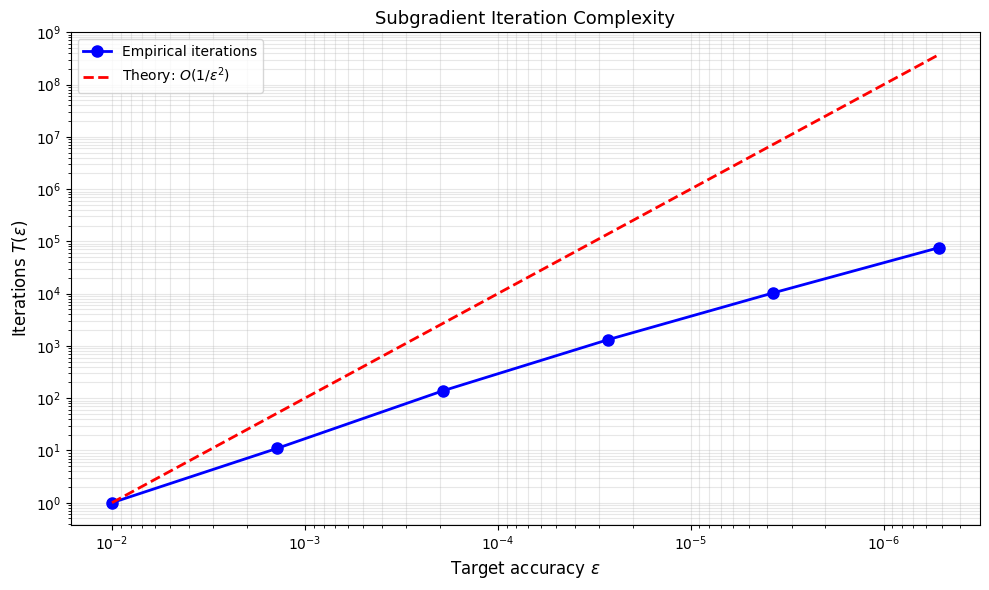

{'epsilons': array([1.00000000e-02, 1.38949549e-03, 1.93069773e-04, 2.68269580e-05,
        3.72759372e-06, 5.17947468e-07]),
 'iterations': array([    1,    11,   138,  1316, 10358, 75648])}

In [6]:
# Define range of epsilons to test
epsilons = np.logspace(-2, -8, 8)  # de 1e-2 à 1e-6


# Plot 2: Complexity vs Precision
plot_subgradient_complexity(model_non_smooth, w0, f_ref, D, M, epsilons, max_iter=100000,
                                 method_name='Subgradient', save_dir=None)

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 90
Final objective value: -0.000242


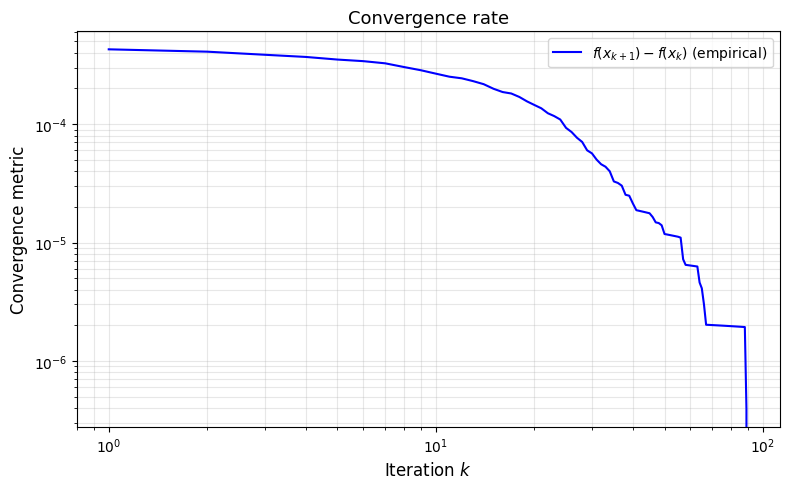

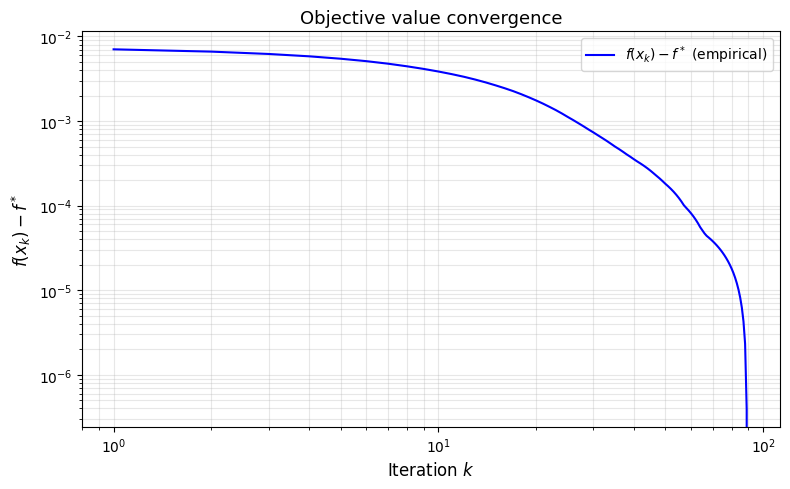

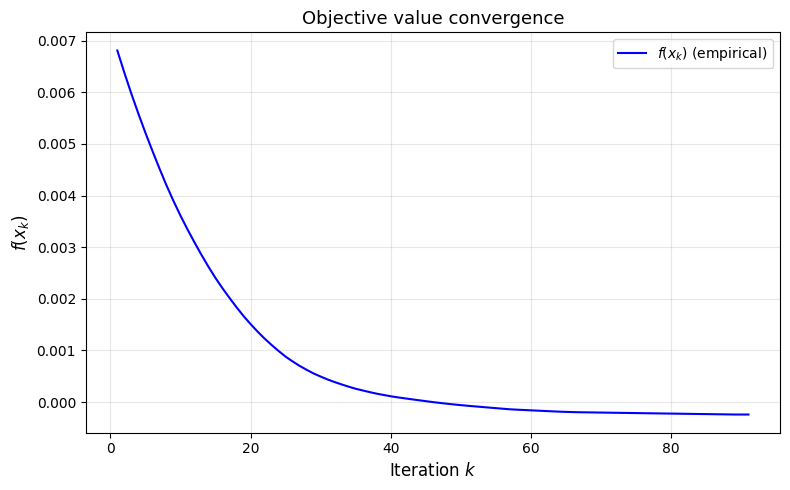

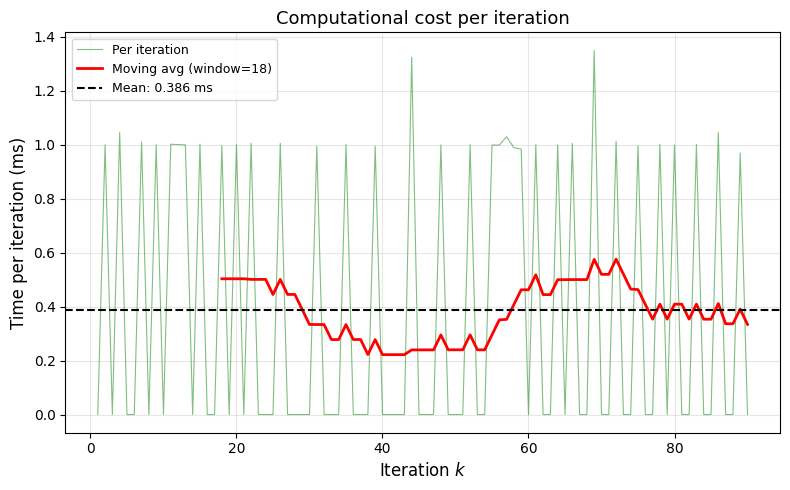

Total time: 0.0348 seconds
Total iterations: 90
Final objective value: -0.000242
Average time per iteration: 0.3861 ms
Std time per iteration: 0.4980 ms


In [7]:
# Proximal Gradient Method
# Use the SAME w0 as subgradient method for fair comparison

method_proximal = ProximalGradientMethod({
    'step_size': 0.01,           # Use 1/L for convergence guarantee
    'max_iter': 10000,
    'tol': 1e-8,
}, ValuePerformanceIndicator())

# Use the SAME w0 as the subgradient method (don't redefine it!)
result_ProximalGradient = method_proximal.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProximalGradient.keys())
print(f"Converged: {result_ProximalGradient['converged']}")
print(f"Iterations: {result_ProximalGradient['iterations']}")
print(f"Final objective value: {result_ProximalGradient['value']:.6f}")


# Plot convergence
plot_convergence(result_ProximalGradient, method_name="Proximal_Gradient_Method", save_dir="../figures", metric_used='function')

  tol=1.00e-02: 1 iterations
  tol=2.15e-03: 1 iterations
  tol=4.64e-04: 1 iterations
  tol=1.00e-04: 1 iterations
  tol=2.15e-05: 140 iterations
  tol=4.64e-06: 321 iterations
  tol=1.00e-06: 499 iterations
  tol=4.64e-06: 321 iterations
  tol=1.00e-06: 499 iterations
  tol=2.15e-07: 681 iterations
  tol=2.15e-07: 681 iterations
  tol=4.64e-08: 732 iterations
  tol=4.64e-08: 732 iterations
  tol=1.00e-08: 732 iterations
  tol=1.00e-08: 732 iterations


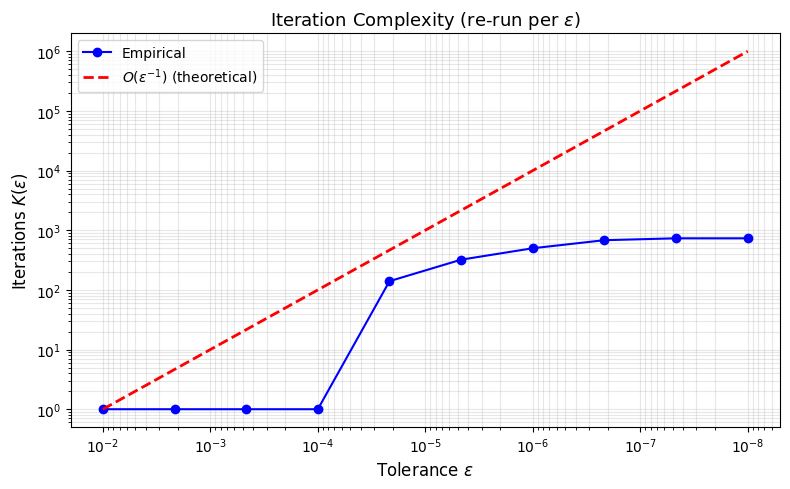

In [8]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-8

result_complexity = measure_iteration_complexity(
    method_class=ProximalGradientMethod,
    method_params={
        'step_size': 0.001,
        'max_iter': 10000,
        'tol': 1e-8,
    },
    model=model_non_smooth,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='ProximalGradientMethod',
    save_dir='../figures',
    metrics='function'
)

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 35
Final objective value: -0.000242


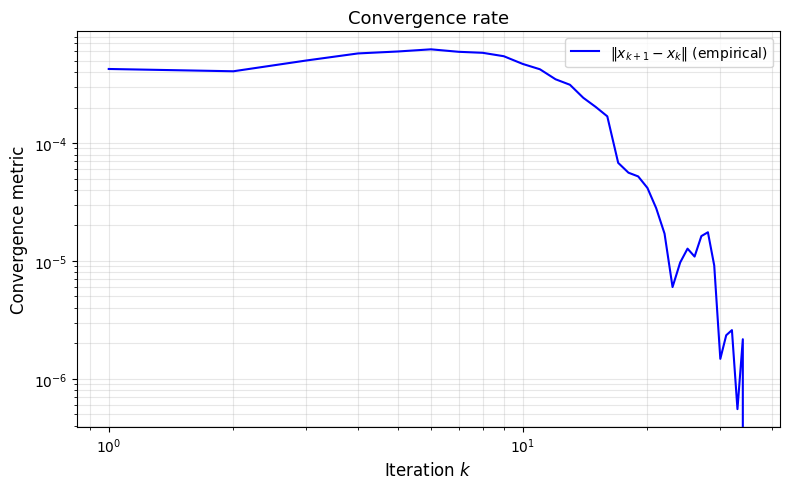

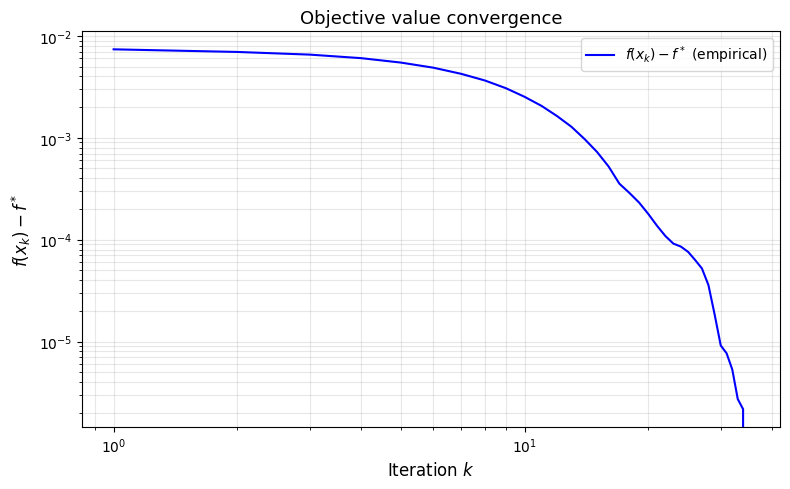

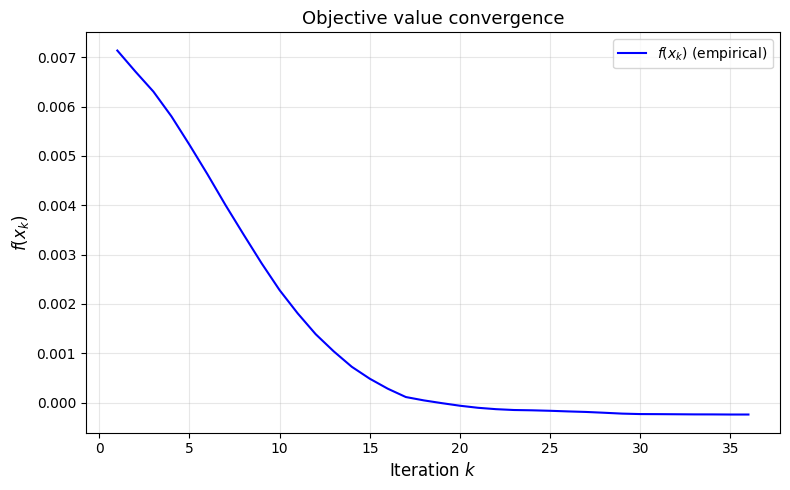

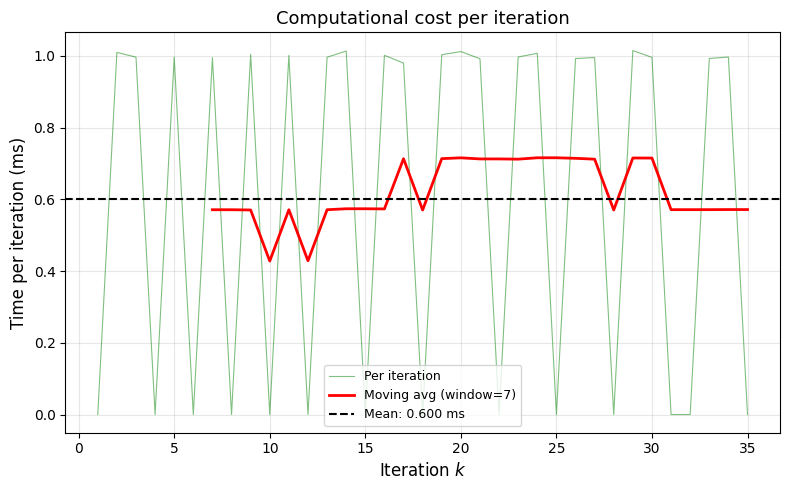

Total time: 0.0210 seconds
Total iterations: 35
Final objective value: -0.000242
Average time per iteration: 0.6000 ms
Std time per iteration: 0.4899 ms


In [9]:
# Constant step size only converges to a neighborhood of the optimum
method = ProximalGradientMethod_fast({
    'step_size': 0.01,              # Initial step size α_0
    'max_iter': 10000,
    'tol': 1e-25,
}, ValuePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0] , method="random")

# Optimize portfolio on training data
result_ProjectedSubgradientMethod = method.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProjectedSubgradientMethod.keys())
print(f"Converged: {result_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result_ProjectedSubgradientMethod['value']:.6f}")

# Plot convergence
plot_convergence(result_ProjectedSubgradientMethod)